# 02 LLM Relation Extraction
Assess the quality of LLM-extracted relations using the BioRED dataset. If they are comparable to the manual annotations, that is a good sign meaning they are likely suitable to be used to fine tune the pretrained model. If they are drastically different, I will likely need to rethink the comparison. 

In [36]:
from pathlib import Path
import pandas as pd
import re

In [2]:
# Dynamically find the directory where this script/notebook lives
current_dir = Path(__file__).resolve().parent if '__file__' in locals() else Path.cwd()
PROJECT_ROOT = current_dir.parent
PROJECT_ROOT

WindowsPath('d:/Users/Jessica/kg-construction')

In [121]:
output_path = PROJECT_ROOT / "outputs" / "02_LLM_RE"

In [12]:
BIORED_1000_FILES = {
    "Train": PROJECT_ROOT / "data" / "00_raw" / "BioRED_1000" / "bc8_biored_task1_train.pubtator",
    "Validation": PROJECT_ROOT / "data" / "00_raw" / "BioRED_1000" / "bc8_biored_task1_val.pubtator",
    "Test": PROJECT_ROOT / "data" / "00_raw" / "BioRED_1000" / "bc8_biored_task1_test.pubtator",
}

BIORED_NCBI_FILES = {
    "Dev": PROJECT_ROOT / "data" / "00_raw" / "biorex" / "ncbi_relation" / "Dev.PubTator",
    "Test": PROJECT_ROOT / "data" / "00_raw" / "biorex" / "ncbi_relation" / "Test.PubTator",
    "Train": PROJECT_ROOT / "data" / "00_raw" / "biorex" / "ncbi_relation" / "Train.PubTator",
}


def count_unique_document_ids(file_path):
    unique_docs = set()

    with open(file_path, "r", encoding="utf-8") as handle:
        for line in handle:
            if "|t|" not in line:
                continue

            doc_id = line.split("|t|", 1)[0].strip()
            if doc_id:
                unique_docs.add(doc_id)

    return len(unique_docs)


def iter_pubtator_entity_mentions(file_path):
    with open(file_path, "r", encoding="utf-8") as handle:
        for line in handle:
            line = line.strip()
            if not line or "|t|" in line or "|a|" in line:
                continue

            parts = line.split("\t")
            if len(parts) >= 6 and parts[1].isdigit() and parts[2].isdigit():
                doc_id = parts[0].strip()
                mention = parts[3].strip()
                entity_id = parts[5].strip()

                if not mention or not entity_id:
                    continue

                for individual_id in entity_id.split(";"):
                    cleaned_id = individual_id.strip()
                    if cleaned_id:
                        yield doc_id, cleaned_id, mention

### BioRED 1000 is unsuitable for this analysis
* In the expanded BioRED dataset of 1000 abstracts
    * The original 600 are available as training data
    * Whereas the additional 400 abstracts they included are concealed in the test set containing 10000 abstracts with their entities annotated. The relation annnotations are with the organizers and not available for me to use
    * https://codalab.lisn.upsaclay.fr/competitions/16381#learn_the_details-dataset
    * https://academic-oup-com.myaccess.library.utoronto.ca/database/article/doi/10.1093/database/baae069/7729400#484143431
* As shown below, there are 500 abstracts in the training set, 1000 in the validation set and 10000 in the test set
* In conclusion, even though the authors now expanded the set from 600 to 1000, the additional 400 is still inaccessible to me. I will pivot back to the original 600 abstract BioRED dataset 

In [13]:
for split_name, file_path in BIORED_1000_FILES.items():
    if not file_path.exists():
        print(f"Warning: {file_path.name} not found. Skipping...")
        continue

    print(f"{split_name} unique documents: {count_unique_document_ids(file_path)}")

Train unique documents: 500
Validation unique documents: 1000
Test unique documents: 10000


### Extract the raw text and unique entities of each abstract
* From the original BioRED dataset containing 600 abstracts

In [17]:
import json
from collections import Counter, defaultdict


def parse_pubtator_documents(file_path):
    """Parse a PubTator file into combined text, entities, and relations."""
    paper_data = defaultdict(lambda: {"text": "", "entities": set(), "relations": set()})
    all_pmids = set()

    with open(file_path, "r", encoding="utf-8") as handle:
        for line in handle:
            line = line.strip()
            if not line:
                continue

            if "|t|" in line or "|a|" in line:
                pmid, _, text_content = line.split("|", 2)
                all_pmids.add(pmid)
                paper_data[pmid]["text"] = f"{paper_data[pmid]['text']} {text_content}".strip()
                continue

            parts = line.split("\t")
            if len(parts) < 4:
                continue

            pmid = parts[0]
            all_pmids.add(pmid)

            if len(parts) >= 6 and parts[1].isdigit() and parts[2].isdigit():
                entity_id = parts[5]
                for individual_id in entity_id.split(";"):
                    cleaned_id = individual_id.strip()
                    if cleaned_id:
                        paper_data[pmid]["entities"].add(cleaned_id)
            else:
                paper_data[pmid]["relations"].add((parts[1], parts[2], parts[3]))

    return all_pmids, paper_data


def parse_pubtator_for_extraction(file_path):
    return parse_pubtator_documents(file_path)


def iter_pubtator_entity_mentions(file_path):
    with open(file_path, "r", encoding="utf-8") as handle:
        for line in handle:
            line = line.strip()
            if not line or "|t|" in line or "|a|" in line:
                continue

            parts = line.split("\t")
            if len(parts) >= 6 and parts[1].isdigit() and parts[2].isdigit():
                doc_id = parts[0].strip()
                mention = parts[3].strip()
                entity_id = parts[5].strip()

                if not doc_id or not mention or not entity_id:
                    continue

                for individual_id in entity_id.split(";"):
                    cleaned_id = individual_id.strip()
                    if cleaned_id:
                        yield doc_id, cleaned_id, mention


def build_per_abstract_canonical_mapping(file_paths):
    abstract_entity_counts = defaultdict(Counter)

    for split_name, path in file_paths.items():
        if not path.exists():
            print(f"Warning: File not found at {path}. Skipping mapping accumulation...")
            continue

        print(f"Scanning {split_name} for per-abstract entity text frequencies...")
        for doc_id, entity_code, mention in iter_pubtator_entity_mentions(path):
            abstract_entity_counts[(doc_id, entity_code)][mention] += 1

    per_abstract_mapping = defaultdict(dict)
    for (doc_id, entity_code), mention_counter in abstract_entity_counts.items():
        per_abstract_mapping[doc_id][entity_code] = mention_counter.most_common(1)[0][0]

    return per_abstract_mapping

In [123]:
llm_ready_corpus = []

for split_name, path in BIORED_NCBI_FILES.items():
    if not path.exists():
        print(f"Warning: File not found at {path}")
        continue

    print(f"Parsing split: {split_name}...")
    _, paper_data = parse_pubtator_documents(path)

    for pmid, data in paper_data.items():
        llm_ready_corpus.append(
            {
                "split": split_name,
                "document_id": pmid,
                "text": data["text"].strip(),
                "entities": sorted(data["entities"]),
                "ground_truth_relations": list(data["relations"]),
            }
        )

print(f"\nSuccessfully prepared {len(llm_ready_corpus)} standalone abstract payloads!")

output_path.mkdir(parents=True, exist_ok=True)
llm_ready_corpus_json_path = output_path / "llm_ready_corpus.json"
with open(llm_ready_corpus_json_path, "w", encoding="utf-8") as handle:
    json.dump(llm_ready_corpus, handle, indent=2, ensure_ascii=False)

print(f"Saved llm_ready_corpus to: {llm_ready_corpus_json_path}")
sample_payload = llm_ready_corpus[0]
sample_preview = {
    "split": sample_payload["split"],
    "document_id": sample_payload["document_id"],
    "text_chars": len(sample_payload["text"]),
    "entity_count": len(sample_payload["entities"]),
    "relation_count": len(sample_payload["ground_truth_relations"]),
}
print("\n--- SAMPLE PAYLOAD SUMMARY ---")
print(json.dumps(sample_preview, indent=2))

Parsing split: Dev...
Parsing split: Test...
Parsing split: Train...

Successfully prepared 600 standalone abstract payloads!
Saved llm_ready_corpus to: d:\Users\Jessica\kg-construction\outputs\02_LLM_RE\llm_ready_corpus.json

--- SAMPLE PAYLOAD SUMMARY ---
{
  "split": "Dev",
  "document_id": "14510914",
  "text_chars": 1920,
  "entity_count": 14,
  "relation_count": 12
}


In [122]:
import os
import json
from collections import defaultdict, Counter

def build_per_abstract_canonical_mapping_with_type(file_paths):
    """
    Scans all dataset splits to build a per-abstract mapping from:
    Document ID -> Entity Code -> { "name": most_frequent_string, "type": most_frequent_type }
    """
    # Key: (document_id, entity_code) -> Value: Counter(mention1=count, mention2=count...)
    abstract_entity_counts = defaultdict(Counter)
    # Key: (document_id, entity_code) -> Value: Counter(type1=count, type2=count...)
    abstract_entity_types = defaultdict(Counter)

    for split_name, path in file_paths.items():
        if not os.path.exists(path):
            print(f"Warning: File not found at {path}. Skipping split...")
            continue
            
        print(f"Scanning {split_name} for per-abstract entity text and type frequencies...")
        
        with open(path, 'r', encoding='utf-8') as f:
            for line in f:
                line = line.strip()
                if not line or '|t|' in line or '|a|' in line:
                    continue
                
                parts = line.split('\t')
                # Validate standard 6-column entity line
                if len(parts) >= 6 and parts[1].isdigit() and parts[2].isdigit():
                    doc_id = parts[0].strip()
                    mention = parts[3].strip()
                    ent_type = parts[4].strip()  # Column containing entity type (e.g., GeneOrGeneProduct)
                    entity_id = parts[5].strip()
                    
                    if entity_id and mention:
                        # Handle composite codes safely
                        for individual_id in entity_id.split(';'):
                            cleaned_id = individual_id.strip()
                            if cleaned_id:
                                # Count frequencies scoped strictly to this document and code combo
                                abstract_entity_counts[(doc_id, cleaned_id)][mention] += 1
                                abstract_entity_types[(doc_id, cleaned_id)][ent_type] += 1

    # Build the rich nested dictionary layout
    per_abstract_mapping = defaultdict(dict)
    
    for (doc_id, entity_code), mention_counter in abstract_entity_counts.items():
        # Get the most common text string representation
        most_frequent_string = mention_counter.most_common(1)[0][0]
        
        # Get the most common entity type assigned to this specific code inside this paper
        type_counter = abstract_entity_types[(doc_id, entity_code)]
        most_frequent_type = type_counter.most_common(1)[0][0]
        
        # Store both inside an organized dict mapping
        per_abstract_mapping[doc_id][entity_code] = {
            "name": most_frequent_string,
            "type": most_frequent_type
        }

    return per_abstract_mapping


if __name__ == "__main__":
    # Assuming BIORED_NCBI_FILES dictionary is defined above
    abstract_maps = build_per_abstract_canonical_mapping_with_type(BIORED_NCBI_FILES)

    print(f"\nGenerated distinct code mappings for {len(abstract_maps)} individual abstracts.")

    output_json_path = os.path.join(output_path, "per_abstract_entity_code_to_name.json")
    with open(output_json_path, "w", encoding="utf-8") as out_f:
        json.dump(abstract_maps, out_f, indent=2, ensure_ascii=False)

    print(f"Saved nested abstract mapping file to: {output_json_path}")
    print("\n--- SAMPLE NESTED DICTIONARY PREVIEW (First Document) ---")
    
    # Safely fetch the first key using standard iterator syntax
    first_doc_id = next(iter(abstract_maps))
    preview_dict = {first_doc_id: abstract_maps[first_doc_id]}
    print(json.dumps(preview_dict, indent=2))

Scanning Dev for per-abstract entity text and type frequencies...
Scanning Test for per-abstract entity text and type frequencies...
Scanning Train for per-abstract entity text and type frequencies...

Generated distinct code mappings for 600 individual abstracts.
Saved nested abstract mapping file to: d:\Users\Jessica\kg-construction\outputs\02_LLM_RE\per_abstract_entity_code_to_name.json

--- SAMPLE NESTED DICTIONARY PREVIEW (First Document) ---
{
  "14510914": {
    "D003409": {
      "name": "congenital hypothyroidism",
      "type": "DiseaseOrPhenotypicFeature"
    },
    "6528": {
      "name": "NIS",
      "type": "GeneOrGeneProduct"
    },
    "C564766": {
      "name": "ITD",
      "type": "DiseaseOrPhenotypicFeature"
    },
    "D050033": {
      "name": "inability of the thyroid",
      "type": "DiseaseOrPhenotypicFeature"
    },
    "D007454": {
      "name": "iodide",
      "type": "ChemicalEntity"
    },
    "9606": {
      "name": "patient",
      "type": "OrganismTaxon"

In [20]:
def extract_all_unique_entity_types(file_paths):
    """
    Scans all dataset splits to find every unique semantic entity type 
    present in column 4 of the entity lines.
    """
    unique_types = set()

    for split_name, path in file_paths.items():
        if not os.path.exists(path):
            continue
            
        with open(path, 'r', encoding='utf-8') as f:
            for line in f:
                line = line.strip()
                if not line or '|t|' in line or '|a|' in line:
                    continue
                
                parts = line.split('\t')
                # Target column 4 (index 4) on valid entity lines
                if len(parts) >= 6 and parts[1].isdigit() and parts[2].isdigit():
                    ent_type = parts[4].strip()
                    if ent_type:
                        unique_types.add(ent_type)

    return sorted(list(unique_types))


if __name__ == "__main__":
    # Assuming BIORED_NCBI_FILES dictionary is defined above
    all_types = extract_all_unique_entity_types(BIORED_NCBI_FILES)
    
    print("=== Unique Entity Types Found in Corpus ===")
    for t in all_types:
        print(f"- {t}")

=== Unique Entity Types Found in Corpus ===
- CellLine
- ChemicalEntity
- DiseaseOrPhenotypicFeature
- GeneOrGeneProduct
- OrganismTaxon
- SequenceVariant


### Extract triples using LLM
* Following the BioRED schema
    * Following these guidelines: https://ftp.ncbi.nlm.nih.gov/pub/lu/BioRED/BioRED_Annotation_Guideline.pdf
* View batch jobs here: https://console.cloud.google.com/agent-platform/batch-predictions?project=gen-lang-client-0862323043
* Previous I used Gemini 2.5 Flash, since then, there have been newer stable models published
    * The only limiting factor is cost. Given an acceptible cost, the more advanced the model is the better.
    * Need it to be comparable to human manual annotations
    * Gemini 2.5 flash has an output price of 1.25USD per 1M tokens
    * Other better models that I could consider:
        * Gemini 2.5 Pro: 5USD per 1M tokens
        * Gemini 3.5 Flash: 4.5USD per 1M tokens

In [28]:
import os
from google import genai
from google.genai import types
from google.genai import errors  # For catching API-specific issues
from google.cloud import storage
from google.genai import Client

In [30]:
import os
from dotenv import load_dotenv
from google import genai

# 1. Load the new key from your local hidden .env file
load_dotenv()

# 2. Initialize the client (it automatically detects GEMINI_API_KEY from os.environ)
client = genai.Client()

# 3. Fire a tiny test request to ensure auth passes
response = client.models.generate_content(
    model='gemini-2.5-flash',
    contents='Test message: Reply with the word Connected.'
)

print(response.text.strip())
# Should output: Connected

Connected


In [31]:
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = r"D:\Users\Jessica\concept_mapping\batch_jobs\gen-lang-client-0862323043-f76fc2fc91b6.json"
PROJECT_ID = "gen-lang-client-0862323043"
LOCATION = "us-central1"
BUCKET_NAME = "jessica-biolink-mapping-bucket"

In [32]:
def submit_gemini_batch(file_path, model_id="gemini-2.5-flash"):
    """
    Uploads a local .jsonl file to GCS and submits a Gemini Batch job.
    
    Args:
        file_path (str): Local path to your input .jsonl file.
        model_id (str): The Gemini model version to use.
        
    Returns:
        str: The submitted Job ID.
    """
    if not os.path.exists(file_path):
        print(f"❌ Error: File not found at {file_path}")
        return None

    # 1. Prepare GCS Paths
    file_name = os.path.basename(file_path)
    # Unique result folder based on input filename
    output_folder = f"results/{file_name.replace('.jsonl', '')}"
    
    # 2. Upload to GCS
    storage_client = storage.Client(project=PROJECT_ID)
    bucket = storage_client.bucket(BUCKET_NAME)
    blob = bucket.blob(file_name)
    blob.upload_from_filename(file_path)
    
    input_uri = f"gs://{BUCKET_NAME}/{file_name}"
    output_uri = f"gs://{BUCKET_NAME}/{output_folder}/"
    
    print(f"✅ Uploaded {file_name} to GCS.")

    # 3. Submit to Gemini
    client = genai.Client(vertexai=True, project=PROJECT_ID, location=LOCATION)
    
    print(f"🚀 Submitting Batch Job to {model_id}...")
    batch_job = client.batches.create(
        model=model_id,
        src=input_uri,
        config={'dest': output_uri}
    )

    job_id = batch_job.name
    print(f"✅ Job submitted successfully!")
    print(f"🆔 Job ID: {job_id}")
    

    return job_id

# --- HOW TO USE ---
# job_id_triples = submit_gemini_batch(output_jsonl_path)

In [34]:
def fetch_gemini_batch_results(job_id, local_input_path):
    """
    Checks the status of a batch job and downloads the results if complete.
    
    Args:
        job_id (str): The ID of the Gemini batch job.
        local_input_path (str): The local path of the original input file 
                                (used to determine where to save the results).
    Returns:
        str: The local path to the downloaded results file, or None if not ready.
    """
    # 1. Initialize Client
    client = Client(
        vertexai=True, 
        project="gen-lang-client-0862323043", 
        location="us-central1"
    )

    # 2. Get Job Status
    print(f"🔍 Checking status for Job: {job_id}...")
    job = client.batches.get(name=job_id)
    
    # Check if job is actually finished
    # We use .name or str() to handle the Enum object correctly
    if "SUCCEEDED" not in str(job.state):
        print(f"⏳ Job is currently in state: {job.state}. Please try again later.")
        return None


    # 3. Extract GCS URI Safely
    if hasattr(job.dest, 'gcs_uri') and job.dest.gcs_uri:
        gcs_uri = job.dest.gcs_uri
    else:
        gcs_uri = getattr(job.dest, 'file_name', str(job.dest))

    # 4. Parse Bucket and Prefix
    path_without_scheme = gcs_uri.replace("gs://", "")
    bucket_name = path_without_scheme.split("/")[0]
    prefix = "/".join(path_without_scheme.split("/")[1:])

    # 5. Define Local Save Path
    download_dir = os.path.dirname(local_input_path)
    file_name = os.path.basename(local_input_path)
    local_result_path = os.path.join(download_dir, f"result_{file_name}")

    # 6. Download the Result Blob
    storage_client = storage.Client()
    blobs = storage_client.list_blobs(bucket_name, prefix=prefix)

    found_any = False
    for blob in blobs:
        # We want the output JSONL, ignoring logs/metadata
        if blob.name.endswith(".jsonl") and "metadata" not in blob.name:
            print(f"📥 Found result! Downloading {blob.name}...")
            blob.download_to_filename(local_result_path)
            print(f"✅ Saved to: {local_result_path}")
            found_any = True
            break

    if not found_any:
        print(f"⚠️ Job succeeded, but no result .jsonl was found in GCS.")
        return None

    return local_result_path

# --- HOW TO USE ---
# result_path = fetch_gemini_batch_results(JOB_ID, output_jsonl_path)

In [39]:
def batch_results_to_df(result_file_path):
    """
    Parses a Gemini Batch result JSONL file into a flat Pandas DataFrame.
    Includes a repair layer for common LLM formatting glitches (non-ASCII, truncation).
    """
    rows = []
    
    if not os.path.exists(result_file_path):
        print(f"❌ File not found: {result_file_path}")
        return pd.DataFrame()

    def repair_json(raw_text):
        """Helper to fix common LLM formatting hallucinations."""
        # 1. Remove non-ASCII characters (fixes the stray Japanese text)
        cleaned = re.sub(r'[^\x00-\x7F]+', '', raw_text)
        cleaned = cleaned.strip()

        # 2. Basic Truncation Repair: Ensure it ends with ']'
        if not cleaned.endswith(']'):
            # If there's a trailing comma before truncation, remove it
            cleaned = re.sub(r',?\s*$', '', cleaned)
            # Find the last valid closing brace to close the array properly
            if '}' in cleaned:
                cleaned = cleaned[:cleaned.rfind('}')+1] + ']'
            else:
                cleaned += ']'
        return cleaned

    with open(result_file_path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
                
            data = None
            try:
                data = json.loads(line)
                custom_id = data.get('id', '').replace('pmid_', '')
                
                # Extract raw text
                raw_text = data['response']['candidates'][0]['content']['parts'][0]['text']
                
                # --- NEW REPAIR LAYER ---
                try:
                    inner_data = json.loads(raw_text)
                except json.JSONDecodeError:
                    # Try to repair the string if direct parsing fails
                    repaired_text = repair_json(raw_text)
                    inner_data = json.loads(repaired_text)
                # ------------------------
                
                # Flatten the data
                if isinstance(inner_data, list):
                    for item in inner_data:
                        if isinstance(item, dict):
                            row = {'pmid': custom_id}
                            row.update(item)
                            rows.append(row)
                elif isinstance(inner_data, dict):
                    row = {'pmid': custom_id}
                    row.update(inner_data)
                    rows.append(row)

            except (KeyError, json.JSONDecodeError, IndexError) as e:
                err_id = data.get('id', 'Unknown') if data else 'Unknown'
                print(f"⚠️ Skipping {err_id} due to parsing error: {e}")

    # Create the DataFrame
    df = pd.DataFrame(rows)
    
    if not df.empty:
        # Reorder to put 'pmid' first for readability
        cols = ['pmid'] + [c for c in df.columns if c != 'pmid']
        df = df[cols]
        print(f"✅ Successfully created DataFrame with {len(df)} rows.")
        print(f"📊 Columns identified: {list(df.columns)}")
    else:
        print("⚠️ No data was successfully parsed.")
        
    return df
# --- HOW TO USE ---
# df_entities = batch_results_to_df("result_entities_batch.jsonl")

In [107]:
import os
import json
from datetime import datetime

# --- CONFIGURATION ---
biored_relation_batch_job = os.path.join(output_path, f"biored_relation_batch_{datetime.now().strftime('%m%d_%H%M')}.jsonl")

# --- 1. DATA PREP ---
batch_requests = []
# corpus_included = llm_ready_corpus[:10] # For the 10 abstract trial
corpus_included = llm_ready_corpus[:] # For the 600 abstract full
print(f"Generating requests from {len(corpus_included)} corpus payloads...")

for payload in corpus_included:
    pmid_str = str(payload["document_id"])
    abstract_text = payload["text"]

    # Retrieve the canonical name/type mapping generated from your file parser step
    # Expects: abstract_maps[pmid][entity_code] = {"name": ..., "type": ...}
    entities_dict = abstract_maps.get(pmid_str, {})

    if not abstract_text or not entities_dict:
        continue

    # --- Group Entities By Type dynamically for the prompt ---
    grouped_entities = {
        "GeneOrGeneProduct": [],
        "ChemicalEntity": [],
        "DiseaseOrPhenotypicFeature": [],
        "SequenceVariant": []
    }

    for ent_id, ent_info in sorted(entities_dict.items()):
        ent_type = ent_info.get("type")
        ent_name = ent_info.get("name")
        if ent_type in grouped_entities:
            grouped_entities[ent_type].append(f"ID: {ent_id} ({ent_name})")

    # Format the grouped blocks visually into text strings
    gene_str = "\n".join([f"- {item}" for item in grouped_entities["GeneOrGeneProduct"]]) or "None listed"
    chem_str = "\n".join([f"- {item}" for item in grouped_entities["ChemicalEntity"]]) or "None listed"
    disease_str = "\n".join([f"- {item}" for item in grouped_entities["DiseaseOrPhenotypicFeature"]]) or "None listed"
    variant_str = "\n".join([f"- {item}" for item in grouped_entities["SequenceVariant"]]) or "None listed"

    # --- 2. THE COMPREHENSIVE BIORED PROMPT ---
    prompt_text = f"""You are an expert biomedical text annotator specializing in relation extraction. Your task is to identify and classify valid biological relationships between a predefined list of entities within the provided text, strictly adhering to the official BioRED relation annotation guidelines.

### Pre-identified Entities for this Abstract
Below are the only valid entities present in this text, grouped by their official BioRED concept types. You must ONLY evaluate relationships between the entity IDs provided below.

#### [GeneOrGeneProduct]
{gene_str}

#### [ChemicalEntity]
{chem_str}

#### [DiseaseOrPhenotypicFeature]
{disease_str}

#### [SequenceVariant]
{variant_str}

---

### Input Text (Abstract)
{abstract_text}

---

### Task Instructions
Review the abstract carefully. Focus ONLY on the entities listed above. Determine if a valid biological relation exists between any pairs of these entities based on the context of the abstract text.

### Novelty Triage Coding Instructions
For every valid biological relationship you extract, you must evaluate its structural context in the paper and assign a novelty triage classification:
- **"Novel":** Assign this if the relation represents the main point, newly discovered findings, or novelty of this specific abstract. Any biological relationship reported as part of the direct results, observations, or conclusions of the current study is considered "Novel".
- **"No":** Assign this if the relation represents background information. This typically includes established knowledge providing context early in the abstract, results cited from previous studies, or historical details used to establish why the current paper is important.

### The Default Catch-All Rule
- **Association:** If the abstract clearly states or establishes a biological link/connection between two entities, but the context is too general, non-specific, or lacks directional evidence to fit into any of the category-specific relations below, classify the relation as **Association**.
  *Note:* If a specific `SequenceVariant` is found to have a relation to a disease, its parent `GeneOrGeneProduct` automatically inherits an `Association` relation to that disease. Likewise, if a `SequenceVariant` is found to have a relation to a `ChemicalEntity`, its parent `GeneOrGeneProduct` automatically inherits the SAME relation type (Association, Positive_Correlation, or Negative_Correlation) to that chemical.

### Specific Relation Mapping Schema
Only use these specific categories if the text provides clear, explicit evidence matching the entity-pair criteria. 
Strict Exclusivity Rule: You must ONLY extract relations that match one of the 7 specific entity-pair combinations listed below. These 7 pairs are the only valid configurations. Any other pairing combination (for example, SequenceVariant to SequenceVariant) is structurally forbidden—if encountered, ignore it completely. Do not invent other pairing logic or relation types.

1. **GeneOrGeneProduct to GeneOrGeneProduct Relations:**
   - **Bind:** Physical interaction, signaling protein-receptor pairs, or members of a protein complex.
     - IMPORTANT OVERRIDE: If the binding interaction is reported together with a directional functional consequence (e.g., "protein A binds protein B and inhibits its activity"), annotate Positive_Correlation or Negative_Correlation instead of Bind. Use Bind only when the physical interaction itself is the endpoint being reported.
     - Do NOT annotate Bind when one gene's product binds the promoter/regulatory region of another gene — this is a Gene-Gene case that is simply not annotated unless it produces a reported directional (Positive/Negative_Correlation) effect.
   - **Positive_Correlation / Negative_Correlation:** Directional regulation, expression changes, or any other directional positive/negative relationship between two genes (e.g., gene A is a transcription factor that upregulates/downregulates gene B).
   - **Association:** Use for modifications (phosphorylation, acetylation, etc.) or any gene-gene link that is stated but doesn't fit Bind or a directional correlation. Do NOT annotate a purely "is_a" or category-membership relationship (e.g., "BRCA1" and "breast and ovarian cancer gene") as a relation.

2. **ChemicalEntity to GeneOrGeneProduct Relations:**
   - **Bind:** A chemical acting as a gene's receptor/ligand, or a chemical binding the promoter of a gene.
     - IMPORTANT OVERRIDE: If the binding is reported together with a directional consequence (e.g., an inhibitor binding and suppressing its target), annotate Positive_Correlation or Negative_Correlation instead of Bind.
   - **Positive_Correlation:** Chemical increases gene/protein expression; higher gene expression causes higher sensitivity to the chemical; the gene causes an over-response to the chemical.
   - **Negative_Correlation:** Chemical decreases gene/protein expression; higher gene expression causes resistance to the chemical (and vice versa); the gene causes resistance to the chemical.
   - **Association:** Any stated chemical-gene link that lacks clear directionality and isn't Bind.
   - Antagonist/agonist/inhibitor/blocker rule: if a sentence names a specific drug/chemical and its target gene, annotate a relation between them (typically Negative_Correlation for an inhibitor, or Bind/Association if no direction is stated). If "<gene> inhibitors/agonists" is used generically for a class of compounds with no specific drug named, treat that entire phrase as the chemical entity.

3. **ChemicalEntity to ChemicalEntity Relations:**
   - **Cotreatment:** Combination therapy — two chemicals explicitly administered together to treat a disease.
   - **Drug_Interaction:** A pharmacodynamic interaction where two drugs interfere with each other (typically reported as a shared adverse event when co-administered).
   - **Conversion:** One chemical is metabolized, synthesized, or converted into another.
   - **Comparison:** The text directly compares two chemicals (e.g., relative efficacy, potency, or side-effect comparison) without establishing a positive/negative correlation, cotreatment, interaction, or conversion relationship.
   - **Positive_Correlation:** Chemical A increases the sensitivity, efficacy, or gene-activating effect of Chemical B.
   - **Negative_Correlation:** Chemical A decreases the sensitivity, efficacy, side effects, or gene-activating effect of Chemical B.
   - **Association:** Use for chemical conversions/metabolic relationships not covered above, or links lacking clear directionality. Do NOT annotate a purely "is_a" relationship (e.g., "nefiracetam is a pyrrolidone derivative") as a relation.

4. **ChemicalEntity to SequenceVariant Relations:**
   - **Positive_Correlation:** The variant causes higher sensitivity or over-response to the chemical; the chemical causes higher expression of the gene specifically because of this variant.
   - **Negative_Correlation:** The variant causes lower sensitivity/resistance to the chemical; the variant has a protective role against a chemical-induced adverse effect.
   - **Association:** The chemical and variant are linked without clear directionality (e.g., the variant sits within a chemical's known binding site, or binding ability is impaired by the variant with no clear positive/negative framing).
   - Whenever a Chemical-Variant relation is annotated, propagate the SAME relation type to the corresponding parent GeneOrGeneProduct-ChemicalEntity pair (see inheritance note above).

5. **DiseaseOrPhenotypicFeature to ChemicalEntity Relations:**
   - **Positive_Correlation:** Chemical-induced disease; higher dose causing higher disease risk; disease causing an increase in the chemical's measured/blood level; chemical exposure altering later disease susceptibility.
   - **Negative_Correlation:** The chemical/drug explicitly treats, prevents, or lowers susceptibility to the disease; disease causing a decrease in the chemical's measured level.
   - **Association:** Use when the pairing is established (e.g., "a safety drug for the potential disease") but doesn't fit a clear positive/negative direction.
   - Toxicity nuance: when a disease/adverse outcome is attributed to a chemical's toxicity or being "drug-induced," annotate the relation between the CHEMICAL and the DISEASE/outcome (Positive_Correlation) — do NOT annotate a relation between the chemical and the word "toxicity" itself as if it were a separate entity.
   - Exclusions: do NOT annotate a disease to a staining/histology chemical (e.g., hematoxylin, DAPI used for imaging) or to inert vehicles (saline, placebo, water).

6. **DiseaseOrPhenotypicFeature to GeneOrGeneProduct Relations:**
   - **Positive_Correlation:** Overexpression/overdose of the protein causes or correlates with the disease; the protein's side effect causes the disease.
   - **Negative_Correlation:** The protein/drug treats or prevents the disease; lack of the protein causes the disease; gene knockout/knockdown causes or correlates with the disease.
   - **Association:** Any disease-gene link that is stated but not clearly directional, including cases where a functional gene prevents disease occurrence, or the relation reflects general protein deficiency.
   - If a variant's relation to this disease is annotated, the corresponding gene automatically inherits an Association relation to the same disease (do not try to infer a stronger directional type for the gene from the variant's relation).

7. **DiseaseOrPhenotypicFeature to SequenceVariant Relations:**
   - **Positive_Correlation:** The variant increases disease risk, causes the gene to be over-expressed or non-functional in a way that raises disease susceptibility, or is a documented "founder mutation" for the disease.
   - **Negative_Correlation:** The variant decreases disease risk.
   - **Association:** The variant is simply observed in patients with the disease, or the inheritance pattern of a genetic disease is confirmed by the variant, without clearly fitting Positive/Negative_Correlation.

### Strict Curation Rules
1. **No Co-occurrence Restriction:** Entities do NOT need to be in the same sentence to have a relation annotated, as long as the abstract clearly establishes the link.
2. **Abstract-Only Evidence:** Do NOT use outside medical knowledge to extrapolate relations. If the evidence in the abstract is vague, missing, or purely speculative, do not annotate it.
3. **Negative/Null Findings:**
   - If the text explicitly refutes or finds no relationship between two entities in the CURRENT study (e.g., "Gene X is NOT a risk factor for Disease Y," "no correlation was observed," "not significant"), do NOT annotate that pair.
   - Exception: if the text reports a previously established association from prior literature (even in passing, and even if the current paper's own findings were non-significant), still annotate that previously-reported association.
4. **The Multi-Chemical Rules:**
   - *For Co-treatment:* Annotate `Negative_Correlation` for Chemical A -> Disease, `Negative_Correlation` for Chemical B -> Disease, AND a `Cotreatment` relation between Chemical A and Chemical B.
   - *For Drug Interactions:* Annotate `Positive_Correlation` for both chemicals to the disease, AND a `Drug_Interaction` relation between the two chemicals.
   - *For an induced-disease chain* (Chemical A induces Disease, Chemical/Protein B treats the induced Disease): annotate all three pairwise relations — A to Disease (Positive_Correlation), B to Disease (Negative_Correlation), and A to B (Negative_Correlation).
5. **Exclusions:**
   - Do NOT annotate prognostic factors of genes or variants to a target disease.
   - Do NOT annotate the association of a disease to staining/histology chemicals (e.g., hematoxylin) or to inert vehicles (saline, placebo, water, juice).
   - Do NOT annotate a purely "is_a" or category-membership relationship between two genes or two chemicals as a relation.
   - Do NOT annotate symptoms of the target disease to a correlated variant/gene unless the text explicitly and clearly links the specific symptom to the specific variant/gene.
6. **One Relation Type Per Pair:** Report the single best-fitting relation type for a given entity pair; do not report the same pair twice with different types unless the abstract clearly describes two distinct, separately-evidenced relationships.

### Output Requirements
Generate a JSON array tracking all extracted relations found using the keys detailed in your schema configuration. If zero valid relations exist in the text based on these guidelines, return an empty array `[]`.
"""

    # --- 3. BATCH STRUCTURE WITH STRICT SCHEMAS ---
    request_node = {
        "id": f"pmid_{pmid_str}",
        "request": {
            "contents": [{"role": "user", "parts": [{"text": prompt_text.strip()}]}],
            "generationConfig": {
                "responseMimeType": "application/json",
                "response_json_schema": {
                    "type": "array",
                    "items": {
                        "type": "object",
                        "properties": {
                            "Entity_1_ID": {"type": "string", "description": "The exact identifier code from the input list for the first entity."},
                            "Entity_1_Name": {"type": "string", "description": "The canonical phrase representation of entity 1."},
                            "Entity_1_Type": {"type": "string", "enum": ["GeneOrGeneProduct", "ChemicalEntity", "DiseaseOrPhenotypicFeature", "SequenceVariant"]},
                            "Relation_Type": {"type": "string", "enum": ["Association", "Bind", "Positive_Correlation", "Negative_Correlation", "Cotreatment", "Drug_Interaction", "Conversion", "Comparison"]},
                            "Entity_2_ID": {"type": "string", "description": "The exact identifier code from the input list for the second entity."},
                            "Entity_2_Name": {"type": "string", "description": "The canonical phrase representation of entity 2."},
                            "Entity_2_Type": {"type": "string", "enum": ["GeneOrGeneProduct", "ChemicalEntity", "DiseaseOrPhenotypicFeature", "SequenceVariant"]},
                            "Novelty_Triage": {"type": "string", "enum": ["Novel", "No"], "description": "Select 'Novel' if the relationship is discovered/reported as a result or conclusion of this paper. Select 'No' if it represents baseline background context or historical knowledge referenced from previous work."},
                            "Evidence_Quote": {"type": "string", "description": "Exact text substring from the abstract supporting this relation extraction."}
                        },
                        "required": [
                            "Entity_1_ID", "Entity_1_Name", "Entity_1_Type",
                            "Relation_Type",
                            "Entity_2_ID", "Entity_2_Name", "Entity_2_Type",
                            "Novelty_Triage", "Evidence_Quote"
                        ]
                    }
                },
                "temperature": 0.1
            }
        }
    }
    batch_requests.append(request_node)

# --- 4. WRITE TO FILE ---
with open(biored_relation_batch_job, "w", encoding='utf-8') as f:
    for entry in batch_requests:
        f.write(json.dumps(entry) + "\n")

print(f"--- BioRED Batch Generation Summary ---")
print(f"✅ Source Payload Array: corpus_included ({len(corpus_included)} abstracts available)")
print(f"✅ Successful Request Packets Mapped: {len(batch_requests)}")
print(f"📂 Batch File Written to: {biored_relation_batch_job}")

Generating requests from 600 corpus payloads...
--- BioRED Batch Generation Summary ---
✅ Source Payload Array: corpus_included (600 abstracts available)
✅ Successful Request Packets Mapped: 600
📂 Batch File Written to: d:\Users\Jessica\kg-construction\outputs\02_LLM_RE\biored_relation_batch_0708_1030.jsonl


#### Gemini 2.5 Flash - 10 Abstract Trial

In [42]:
triple_extraction_job_id = submit_gemini_batch(biored_relation_batch_job)

✅ Uploaded biored_relation_batch_0707_1311.jsonl to GCS.
🚀 Submitting Batch Job to gemini-2.5-flash...
✅ Job submitted successfully!
🆔 Job ID: projects/534116064145/locations/us-central1/batchPredictionJobs/150149866234839040


In [76]:
triple_extraction_result_path = fetch_gemini_batch_results(triple_extraction_job_id, biored_relation_batch_job)

🔍 Checking status for Job: projects/534116064145/locations/us-central1/batchPredictionJobs/150149866234839040...
📥 Found result! Downloading results/biored_relation_batch_0707_1311/prediction-model-2026-07-07T17:11:55.687167Z/predictions.jsonl...
✅ Saved to: d:\Users\Jessica\kg-construction\outputs\02_LLM_RE\result_biored_relation_batch_0707_1311.jsonl


In [77]:
triple_extraction_df = batch_results_to_df(triple_extraction_result_path)

# Display the result
print(f"✅ Total triples extracted: {len(triple_extraction_df)}")
display(triple_extraction_df.head(5))

✅ Successfully created DataFrame with 77 rows.
📊 Columns identified: ['pmid', 'Entity_1_ID', 'Entity_1_Name', 'Entity_1_Type', 'Relation_Type', 'Entity_2_ID', 'Entity_2_Name', 'Entity_2_Type', 'Novelty_Triage', 'Evidence_Quote']
✅ Total triples extracted: 77


,pmid,Entity_1_ID,Entity_1_Name,Entity_1_Type,Relation_Type,Entity_2_ID,Entity_2_Name,Entity_2_Type,Novelty_Triage,Evidence_Quote
0,15096016,D010300,PD,DiseaseOrPhenotypicFeature,Association,D004409,dyskinesias,DiseaseOrPhenotypicFeature,No,"PD, such as dyskinesias"
1,15096016,D010300,PD,DiseaseOrPhenotypicFeature,Association,D009127,rigidity,DiseaseOrPhenotypicFeature,No,"PD, such as rigidity"
2,15096016,D010300,PD,DiseaseOrPhenotypicFeature,Association,D018476,bradykinesia,DiseaseOrPhenotypicFeature,No,"PD, such as bradykinesia"
3,15096016,D007980,levodopa,ChemicalEntity,Positive_Correlation,D004409,dyskinesias,DiseaseOrPhenotypicFeature,No,levodopa-induced dyskinesias
4,16277682,rs771966860,M404V,SequenceVariant,Positive_Correlation,C538098,PDB,DiseaseOrPhenotypicFeature,Novel,"Taken together, these results support a genoty..."


In [96]:
import pandas as pd
import numpy as np

def get_filtered_predictions(triple_extraction_df):
    """
    Applies BioRED schema constraints, cleans data fields, and standardizes 
    entity directions for downstream evaluation.
    
    Args:
        triple_extraction_df (pd.DataFrame): Raw relation extraction data from the LLM.
        
    Returns:
        pd.DataFrame: Cleaned, schema-filtered predictions with sorted entity columns.
    """
    # 1. Define allowed entity-type pairs (direction-agnostic)
    ALLOWED_PAIRS = {
        frozenset({"GeneOrGeneProduct", "GeneOrGeneProduct"}),
        frozenset({"ChemicalEntity", "GeneOrGeneProduct"}),
        frozenset({"ChemicalEntity", "ChemicalEntity"}),
        frozenset({"ChemicalEntity", "SequenceVariant"}),
        frozenset({"DiseaseOrPhenotypicFeature", "ChemicalEntity"}),
        frozenset({"DiseaseOrPhenotypicFeature", "GeneOrGeneProduct"}),
        frozenset({"DiseaseOrPhenotypicFeature", "SequenceVariant"})
    }
    
    # 2. Row-by-row schema validation
    def is_valid_pair(row):
        current_pair = frozenset({row['Entity_1_Type'], row['Entity_2_Type']})
        return current_pair in ALLOWED_PAIRS
    
    # 3. Filter and create an explicit copy to prevent setting-with-copy warnings
    df_pred = triple_extraction_df[triple_extraction_df.apply(is_valid_pair, axis=1)].copy()
    
    if df_pred.empty:
        return pd.DataFrame(columns=list(triple_extraction_df.columns) + ['Sorted_Ent_Min', 'Sorted_Ent_Max'])
        
    # 4. Clean up strings and standardize field types
    for col in ['pmid', 'Entity_1_ID', 'Entity_2_ID', 'Relation_Type']:
        df_pred[col] = df_pred[col].astype(str).str.strip()
        
    # 5. Standardize pair direction (Lexicographical Sorting)
    ent1 = df_pred['Entity_1_ID']
    ent2 = df_pred['Entity_2_ID']
    df_pred['Sorted_Ent_Min'] = np.where(ent1 < ent2, ent1, ent2)
    df_pred['Sorted_Ent_Max'] = np.where(ent1 < ent2, ent2, ent1)
    
    return df_pred

In [97]:
gemini_2_5_flash_df_pred = get_filtered_predictions(triple_extraction_df)

#### Gemini 2.5 Pro - 10 Abstract Trial

In [79]:
gemini_2_5_pro_triple_extraction_job_id = submit_gemini_batch(biored_relation_batch_job, model_id="gemini-2.5-pro")

✅ Uploaded biored_relation_batch_0707_1501.jsonl to GCS.
🚀 Submitting Batch Job to gemini-2.5-pro...
✅ Job submitted successfully!
🆔 Job ID: projects/534116064145/locations/us-central1/batchPredictionJobs/1709099024746807296


In [80]:
gemini_2_5_pro_triple_extraction_result_path = fetch_gemini_batch_results(gemini_2_5_pro_triple_extraction_job_id, biored_relation_batch_job)

🔍 Checking status for Job: projects/534116064145/locations/us-central1/batchPredictionJobs/1709099024746807296...
📥 Found result! Downloading results/biored_relation_batch_0707_1501/prediction-model-2026-07-07T19:01:59.277829Z/predictions.jsonl...
✅ Saved to: d:\Users\Jessica\kg-construction\outputs\02_LLM_RE\result_biored_relation_batch_0707_1501.jsonl


In [81]:
gemini_2_5_pro_triple_extraction_df = batch_results_to_df(gemini_2_5_pro_triple_extraction_result_path)

# Display the result
print(f"✅ Total triples extracted: {len(gemini_2_5_pro_triple_extraction_df)}")
display(gemini_2_5_pro_triple_extraction_df.head(5))

✅ Successfully created DataFrame with 66 rows.
📊 Columns identified: ['pmid', 'Entity_1_ID', 'Entity_1_Name', 'Entity_1_Type', 'Relation_Type', 'Entity_2_ID', 'Entity_2_Name', 'Entity_2_Type', 'Novelty_Triage', 'Evidence_Quote']
✅ Total triples extracted: 66


,pmid,Entity_1_ID,Entity_1_Name,Entity_1_Type,Relation_Type,Entity_2_ID,Entity_2_Name,Entity_2_Type,Novelty_Triage,Evidence_Quote
0,16867246,D014150,antipsychotic drugs,ChemicalEntity,Positive_Correlation,D001480,EPS,DiseaseOrPhenotypicFeature,No,Extrapyramidal syndrome (EPS) is most commonly...
1,16867246,D014150,antipsychotic drugs,ChemicalEntity,Bind,1813,DRD2,GeneOrGeneProduct,No,typical antipsychotic drugs that have a high a...
2,16867246,1813,DRD2,GeneOrGeneProduct,Association,D012559,schizophrenic,DiseaseOrPhenotypicFeature,No,many research groups have reported on the posi...
3,16867246,D002746,chlorpromazine,ChemicalEntity,Positive_Correlation,D001480,EPS,DiseaseOrPhenotypicFeature,No,chlorpromazine-induced EPS
4,16867246,D002746,chlorpromazine,ChemicalEntity,Negative_Correlation,D012559,schizophrenic,DiseaseOrPhenotypicFeature,No,schizophrenic inpatients ... treated with chlo...


In [94]:
gemini_2_5_pro_df_pred = get_filtered_predictions(gemini_2_5_pro_triple_extraction_df)

#### Gemini 2.5 Flash - 600 Abstracts Full

In [108]:
full_triple_extraction_job_id = submit_gemini_batch(biored_relation_batch_job, model_id="gemini-2.5-flash")

✅ Uploaded biored_relation_batch_0708_1030.jsonl to GCS.
🚀 Submitting Batch Job to gemini-2.5-flash...
✅ Job submitted successfully!
🆔 Job ID: projects/534116064145/locations/us-central1/batchPredictionJobs/7723805860681482240


In [109]:
full_triple_extraction_result_path = fetch_gemini_batch_results(full_triple_extraction_job_id, biored_relation_batch_job)

🔍 Checking status for Job: projects/534116064145/locations/us-central1/batchPredictionJobs/7723805860681482240...
📥 Found result! Downloading results/biored_relation_batch_0708_1030/prediction-model-2026-07-08T14:32:47.666572Z/predictions.jsonl...
✅ Saved to: d:\Users\Jessica\kg-construction\outputs\02_LLM_RE\result_biored_relation_batch_0708_1030.jsonl


In [110]:
full_triple_extraction_df = batch_results_to_df(full_triple_extraction_result_path)

# Display the result
print(f"✅ Total triples extracted: {len(full_triple_extraction_df)}")
display(full_triple_extraction_df.head(5))

✅ Successfully created DataFrame with 6121 rows.
📊 Columns identified: ['pmid', 'Entity_1_ID', 'Entity_1_Name', 'Entity_1_Type', 'Relation_Type', 'Entity_2_ID', 'Entity_2_Name', 'Entity_2_Type', 'Novelty_Triage', 'Evidence_Quote']
✅ Total triples extracted: 6121


,pmid,Entity_1_ID,Entity_1_Name,Entity_1_Type,Relation_Type,Entity_2_ID,Entity_2_Name,Entity_2_Type,Novelty_Triage,Evidence_Quote
0,18340638,D001379,azathioprine,ChemicalEntity,Positive_Correlation,D000740,anemia,DiseaseOrPhenotypicFeature,No,The side effects of azathioprine include anemia
1,18340638,D000740,anemia,DiseaseOrPhenotypicFeature,Positive_Correlation,D010718,PS,ChemicalEntity,No,anemia could result from accelerated suicidal ...
2,18340638,D001379,azathioprine,ChemicalEntity,Positive_Correlation,D010718,PS,ChemicalEntity,Novel,erythrocytes from patients indeed showed a sig...
3,18340638,308,annexin V,GeneOrGeneProduct,Bind,D010718,PS,ChemicalEntity,No,"According to annexin V binding, erythrocytes f..."
4,18340638,C059715,Fluo3,ChemicalEntity,Association,D002118,Ca2+,ChemicalEntity,No,cytosolic Ca2+ activity (Fluo3 fluorescence)


In [113]:
full_triple_extraction_df_pred = get_filtered_predictions(full_triple_extraction_df)

### Cost Analysis - 10 Abstract Trial

In [64]:
import json

def calculate_batch_experiment_cost(file_path: str, cost_per_1m_input: float = 0.5, cost_per_1m_output: float = 1.25):
    """
    Calculates and prints a detailed token and cost breakdown report for a Vertex AI batch prediction job.
    
    Args:
        file_path (str): Path to the input JSONL results file.
        cost_per_1m_input (float): Cost in USD per 1 million input tokens. Default is 0.5 (Gemini 2.5 Flash).
        cost_per_1m_output (float): Cost in USD per 1 million output/thinking tokens. Default is 1.25 (Gemini 2.5 Flash).
    """
    total_input_tokens = 0
    total_visible_output_tokens = 0
    total_thinking_tokens = 0
    line_count = 0

    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            
            data = json.loads(line)
            line_count += 1
            
            # Dig into the vertex response structure
            response = data.get("response", {})
            usage = response.get("usageMetadata", {})
            
            if usage:
                total_input_tokens += usage.get("promptTokenCount", 0)
                total_visible_output_tokens += usage.get("candidatesTokenCount", 0)
                total_thinking_tokens += usage.get("thoughtsTokenCount", 0)

    # Total billable output tokens is the sum of both visible and hidden reasoning tokens
    total_billable_output_tokens = total_visible_output_tokens + total_thinking_tokens

    # --- COST CALCULATION ---
    input_cost = (total_input_tokens / 1_000_000) * cost_per_1m_input
    output_cost = (total_billable_output_tokens / 1_000_000) * cost_per_1m_output
    total_cost = input_cost + output_cost

    # --- AVERAGES CALCULATIONS ---
    if line_count > 0:
        avg_input_per_abstract = int(round(total_input_tokens / line_count))
        avg_visible_per_abstract = int(round(total_visible_output_tokens / line_count))
        avg_thinking_per_abstract = int(round(total_thinking_tokens / line_count))
        avg_billable_output_per_abstract = int(round(total_billable_output_tokens / line_count))
        avg_cost_per_abstract = total_cost / line_count
    else:
        avg_input_per_abstract = avg_visible_per_abstract = avg_thinking_per_abstract = avg_billable_output_per_abstract = 0
        avg_cost_per_abstract = 0.0

    print("=============================================")
    print(f"💰 EXACT BATCH EXPERIMENT COST REPORT")
    print(f"   (Processed {line_count} abstracts)")
    print("=============================================")
    print(f"📥 Total Input Tokens      : {total_input_tokens:,}")
    print(f"📤 Total Billable Output  : {total_billable_output_tokens:,}")
    print(f"   ├── Visible Candidates  : {total_visible_output_tokens:,}")
    print(f"   └── Hidden Reasoning    : {total_thinking_tokens:,}")
    print("---------------------------------------------")
    print(f"📊 AVERAGES PER ABSTRACT")
    print("---------------------------------------------")
    print(f"📥 Avg Input Tokens        : {avg_input_per_abstract:,}")
    print(f"📤 Avg Billable Output     : {avg_billable_output_per_abstract:,}")
    print(f"   ├── Avg Visible Gen     : {avg_visible_per_abstract:,}")
    print(f"   └── Avg Hidden Thoughts : {avg_thinking_per_abstract:,}")
    print("---------------------------------------------")
    print(f"💵 Input Cost               : ${input_cost:.4f}")
    print(f"💵 Output Cost              : ${output_cost:.4f}")
    print(f"💎 Total Experiment Cost   : ${total_cost:.4f}")
    print("---------------------------------------------")
    print(f"🏷️  Avg Cost per Abstract    : ${avg_cost_per_abstract:.5f}")
    print("=============================================")

In [73]:
# Option 1: Use defaults (Gemini 2.5 Flash)
calculate_batch_experiment_cost(triple_extraction_result_path)

💰 EXACT BATCH EXPERIMENT COST REPORT
   (Processed 10 abstracts)
📥 Total Input Tokens      : 30,581
📤 Total Billable Output  : 67,809
   ├── Visible Candidates  : 12,698
   └── Hidden Reasoning    : 55,111
---------------------------------------------
📊 AVERAGES PER ABSTRACT
---------------------------------------------
📥 Avg Input Tokens        : 3,058
📤 Avg Billable Output     : 6,781
   ├── Avg Visible Gen     : 1,270
   └── Avg Hidden Thoughts : 5,511
---------------------------------------------
💵 Input Cost               : $0.0153
💵 Output Cost              : $0.0848
💎 Total Experiment Cost   : $0.1001
---------------------------------------------
🏷️  Avg Cost per Abstract    : $0.01001


In [82]:
# Option 2: Override for Gemini 2.5 Pro ($0.625 input / $5.00 output)
calculate_batch_experiment_cost(
    file_path=gemini_2_5_pro_triple_extraction_result_path, 
    cost_per_1m_input=0.625, 
    cost_per_1m_output=5.00
)

💰 EXACT BATCH EXPERIMENT COST REPORT
   (Processed 10 abstracts)
📥 Total Input Tokens      : 30,581
📤 Total Billable Output  : 60,250
   ├── Visible Candidates  : 10,698
   └── Hidden Reasoning    : 49,552
---------------------------------------------
📊 AVERAGES PER ABSTRACT
---------------------------------------------
📥 Avg Input Tokens        : 3,058
📤 Avg Billable Output     : 6,025
   ├── Avg Visible Gen     : 1,070
   └── Avg Hidden Thoughts : 4,955
---------------------------------------------
💵 Input Cost               : $0.0191
💵 Output Cost              : $0.3013
💎 Total Experiment Cost   : $0.3204
---------------------------------------------
🏷️  Avg Cost per Abstract    : $0.03204


In [63]:
import json

total_input_tokens = 0
total_visible_output_tokens = 0
total_thinking_tokens = 0
line_count = 0

with open(triple_extraction_result_path, "r", encoding="utf-8") as f:
    for line in f:
        if not line.strip():
            continue
        
        data = json.loads(line)
        line_count += 1
        
        # Dig into the vertex response structure
        response = data.get("response", {})
        usage = response.get("usageMetadata", {})
        
        if usage:
            total_input_tokens += usage.get("promptTokenCount", 0)
            total_visible_output_tokens += usage.get("candidatesTokenCount", 0)
            total_thinking_tokens += usage.get("thoughtsTokenCount", 0)

# Total billable output tokens is the sum of both visible and hidden reasoning tokens
total_billable_output_tokens = total_visible_output_tokens + total_thinking_tokens

# --- COST CALCULATION (Gemini 2.5 Flash Standard Pricing) ---
# $0.5 per 1M input tokens, $1.25 per 1M output tokens
input_cost = (total_input_tokens / 1_000_000) * 0.5
output_cost = (total_billable_output_tokens / 1_000_000) * 1.25
total_cost = input_cost + output_cost

# --- AVERAGES CALCULATIONS ---
if line_count > 0:
    # Use round() and int() to drop decimal components cleanly
    avg_input_per_abstract = int(round(total_input_tokens / line_count))
    avg_visible_per_abstract = int(round(total_visible_output_tokens / line_count))
    avg_thinking_per_abstract = int(round(total_thinking_tokens / line_count))
    avg_billable_output_per_abstract = int(round(total_billable_output_tokens / line_count))
    avg_cost_per_abstract = total_cost / line_count
else:
    avg_input_per_abstract = avg_visible_per_abstract = avg_thinking_per_abstract = avg_billable_output_per_abstract = 0
    avg_cost_per_abstract = 0.0

print("=============================================")
print(f"💰 EXACT BATCH EXPERIMENT COST REPORT")
print(f"   (Processed {line_count} abstracts)")
print("=============================================")
print(f"📥 Total Input Tokens      : {total_input_tokens:,}")
print(f"📤 Total Billable Output  : {total_billable_output_tokens:,}")
print(f"   ├── Visible Candidates  : {total_visible_output_tokens:,}")
print(f"   └── Hidden Reasoning    : {total_thinking_tokens:,}")
print("---------------------------------------------")
print(f"📊 AVERAGES PER ABSTRACT")
print("---------------------------------------------")
print(f"📥 Avg Input Tokens        : {avg_input_per_abstract:,}")
print(f"📤 Avg Billable Output     : {avg_billable_output_per_abstract:,}")
print(f"   ├── Avg Visible Gen     : {avg_visible_per_abstract:,}")
print(f"   └── Avg Hidden Thoughts : {avg_thinking_per_abstract:,}")
print("---------------------------------------------")
print(f"💵 Input Cost               : ${input_cost:.4f}")
print(f"💵 Output Cost              : ${output_cost:.4f}")
print(f"💎 Total Experiment Cost   : ${total_cost:.4f}")
print("---------------------------------------------")
print(f"🏷️  Avg Cost per Abstract    : ${avg_cost_per_abstract:.5f}")
print("=============================================")

💰 EXACT BATCH EXPERIMENT COST REPORT
   (Processed 10 abstracts)
📥 Total Input Tokens      : 30,581
📤 Total Billable Output  : 67,809
   ├── Visible Candidates  : 12,698
   └── Hidden Reasoning    : 55,111
---------------------------------------------
📊 AVERAGES PER ABSTRACT
---------------------------------------------
📥 Avg Input Tokens        : 3,058
📤 Avg Billable Output     : 6,781
   ├── Avg Visible Gen     : 1,270
   └── Avg Hidden Thoughts : 5,511
---------------------------------------------
💵 Input Cost               : $0.0153
💵 Output Cost              : $0.0848
💎 Total Experiment Cost   : $0.1001
---------------------------------------------
🏷️  Avg Cost per Abstract    : $0.01001


### Evaluate triples against BioRED annotations
* While the prompt requires the LLM to stick stictly to the specified entity pairs, it sometimes does not follow the instructions exactly. e.g. it is still extracting relations between two DiseaseOrPhenotypicFeature type entities. Before doing the comparison, I filter these out with the code below. The scores increased after this.
* While in the BioRED paper, 8 entity type pairs were discussed, the annotation guideline included only 7 different relation types
    * In the paper they briefly mention how that <V,V> has an F-score of 0% for the two models. Maybe this is why they left them out?
    * The authors explicitly mention how the number of relations for <D, V>, <C, V> and <V, V> are low

In [117]:
import pandas as pd
import numpy as np

def evaluate_biored_predictions(triple_extraction_df, llm_ready_corpus, max_examples=3):
    """
    Filters raw LLM relationship predictions based on valid BioRED entity pair schemas, 
    evaluates them against BioRED ground truth data using both Micro and Macro-averaged
    f1-scores, and prints comprehensive error analysis examples.
    
    Args:
        triple_extraction_df (pd.DataFrame): Raw model extraction dataframe.
        llm_ready_corpus (list): The original corpus list containing ground truth relations.
        max_examples (int): Maximum number of error analysis examples to print per category.
        
    Returns:
        dict: A nested dictionary containing Micro and Macro evaluation metrics.
    """
    # --- 1. SCHEMA ENFORCEMENT FILTERING ---
    ALLOWED_PAIRS = {
        frozenset({"GeneOrGeneProduct", "GeneOrGeneProduct"}),
        frozenset({"ChemicalEntity", "GeneOrGeneProduct"}),
        frozenset({"ChemicalEntity", "ChemicalEntity"}),
        frozenset({"ChemicalEntity", "SequenceVariant"}),
        frozenset({"DiseaseOrPhenotypicFeature", "ChemicalEntity"}),
        frozenset({"DiseaseOrPhenotypicFeature", "GeneOrGeneProduct"}),
        frozenset({"DiseaseOrPhenotypicFeature", "SequenceVariant"})
    }

    initial_count = len(triple_extraction_df)

    def is_valid_pair(row):
        current_pair = frozenset({row['Entity_1_Type'], row['Entity_2_Type']})
        return current_pair in ALLOWED_PAIRS

    filtered_extraction_df = triple_extraction_df[triple_extraction_df.apply(is_valid_pair, axis=1)].copy()
    dropped_count = initial_count - len(filtered_extraction_df)

    print("==================================================")
    print("          SCHEMA ENFORCEMENT FILTER SUMMARY        ")
    print("==================================================")
    print(f"Total raw predictions from LLM : {initial_count}")
    print(f"Dropped invalid relations      : {dropped_count}")
    print(f"Valid schema predictions kept  : {len(filtered_extraction_df)}")
    print("==================================================\n")

    # --- 2. EXTRACT GOLD TRUTH WITH CORRECTED INDEXES ---
    processed_pmids = set(triple_extraction_df['pmid'].astype(str).str.strip().unique())

    gold_records = []
    for payload in llm_ready_corpus:
        pmid_str = str(payload["document_id"]).strip()
        
        if pmid_str in processed_pmids:
            for rel in payload["ground_truth_relations"]:
                gold_records.append({
                    "pmid": pmid_str,
                    "Entity_1_ID": str(rel[1]).strip(),
                    "Entity_2_ID": str(rel[2]).strip(),
                    "Relation_Type": str(rel[0]).strip()
                })

    if gold_records:
        df_true = pd.DataFrame(gold_records)
    else:
        df_true = pd.DataFrame(columns=["pmid", "Entity_1_ID", "Entity_2_ID", "Relation_Type"])

    # --- 3. CLEAN AND PREPARE PREDICTIONS ---
    df_pred = filtered_extraction_df.copy()
    for col in ['pmid', 'Entity_1_ID', 'Entity_2_ID', 'Relation_Type']:
        df_pred[col] = df_pred[col].astype(str).str.strip()

    # --- 4. STANDARDIZE PAIR DIRECTION (Lexicographical Sorting) ---
    for df in [df_pred, df_true]:
        if df.empty:
            continue
        ent1 = df['Entity_1_ID']
        ent2 = df['Entity_2_ID']
        
        df['Sorted_Ent_Min'] = np.where(ent1 < ent2, ent1, ent2)
        df['Sorted_Ent_Max'] = np.where(ent1 < ent2, ent2, ent1)

    # --- 5. METRIC CALCULATION UTILITY ---
    def calculate_metrics(true_set, pred_set):
        tp = len(true_set.intersection(pred_set))
        fp = len(pred_set - true_set)
        fn = len(true_set - pred_set)
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
        
        return {
            "True Positives (TP)": tp,
            "False Positives (FP)": fp,
            "False Negatives (FN)": fn,
            "Precision": round(precision, 4),
            "Recall": round(recall, 4),
            "F1-Score": round(f1, 4)
        }

    # --- 6. COMPUTE GLOBAL POOLED SETS ---
    true_pairs = set(zip(df_true['pmid'], df_true['Sorted_Ent_Min'], df_true['Sorted_Ent_Max'])) if not df_true.empty else set()
    pred_pairs = set(zip(df_pred['pmid'], df_pred['Sorted_Ent_Min'], df_pred['Sorted_Ent_Max'])) if not df_pred.empty else set()
    metrics_pairs = calculate_metrics(true_pairs, pred_pairs)

    true_relations = set(zip(df_true['pmid'], df_true['Sorted_Ent_Min'], df_true['Sorted_Ent_Max'], df_true['Relation_Type'])) if not df_true.empty else set()
    pred_relations = set(zip(df_pred['pmid'], df_pred['Sorted_Ent_Min'], df_pred['Sorted_Ent_Max'], df_pred['Relation_Type'])) if not df_pred.empty else set()
    
    # Micro Metrics (Global Pool Allocation)
    micro_metrics_relations = calculate_metrics(true_relations, pred_relations)

    # --- 7. COMPUTE MACRO METRICS (Per Relation Type) ---
    all_relation_types = set(df_true['Relation_Type'].unique()).union(set(df_pred['Relation_Type'].unique()))
    
    macro_precisions = []
    macro_recalls = []
    macro_f1s = []
    per_class_breakdown = {}

    for rel_type in all_relation_types:
        # Filter global sets down to individual relation target
        class_true = {t for t in true_relations if t[3] == rel_type}
        class_pred = {p for p in pred_relations if p[3] == rel_type}
        
        class_metrics = calculate_metrics(class_true, class_pred)
        per_class_breakdown[rel_type] = class_metrics
        
        macro_precisions.append(class_metrics["Precision"])
        macro_recalls.append(class_metrics["Recall"])
        macro_f1s.append(class_metrics["F1-Score"])

    macro_metrics_relations = {
        "Precision": round(np.mean(macro_precisions), 4) if macro_precisions else 0.0,
        "Recall": round(np.mean(macro_recalls), 4) if macro_recalls else 0.0,
        "F1-Score": round(np.mean(macro_f1s), 4) if macro_f1s else 0.0
    }

    # --- 8. PRINT SUMMARY REPORT ---
    print("==================================================")
    print("           BIORED TRIAL EVALUATION REPORT          ")
    print(f"        (Evaluating across {len(processed_pmids)} parsed PMIDs)       ")
    print("==================================================")
    print(f"Gold Ground Truth Relations Found: {len(df_true)}")
    print(f"Model Predicted Relations Found:  {len(df_pred)}")
    print("--------------------------------------------------")
    print("\n📊 LEVEL 1: Entity Pairs Only (Relaxed Validation)")
    print("--------------------------------------------------")
    for k, v in metrics_pairs.items():
        print(f"{k:<25}: {v}")

    print("\n🎯 LEVEL 2: Entity Pairs + Relation Type (Strict Micro Validation)")
    print("--------------------------------------------------")
    for k, v in micro_metrics_relations.items():
        print(f"{k:<25}: {v}")
        
    print("\n🏁 LEVEL 2: Macro-Averaged Evaluation Scores (Equal Class Weights)")
    print("--------------------------------------------------")
    for k, v in macro_metrics_relations.items():
        print(f"Macro {k:<20}: {v}")
    print("==================================================\n")

    # --- 9. ERROR ANALYSIS ---
    tp_examples = true_relations.intersection(pred_relations)
    fp_examples = pred_relations - true_relations
    fn_examples = true_relations - pred_relations

    print("==================================================")
    print("      🔍 ERROR ANALYSIS EXAMPLES (STRICT LEVEL 2) ")
    print("==================================================")
    
    print(f"\n✅ TRUE POSITIVES (TP) - Top {max_examples}:")
    print("Description: Model predicted the relation perfectly.")
    if tp_examples:
        for i, item in enumerate(list(tp_examples)[:max_examples], 1):
            print(f"  {i}. PMID: {item[0]} | Entities: ({item[1]} ↔ {item[2]}) | Type: {item[3]}")
    else:
        print("  None found.")

    intersecting_pairs = true_pairs.intersection(pred_pairs)
    mismatch_examples = []
    
    for pmid, e1, e2 in intersecting_pairs:
        true_types = df_true[(df_true['pmid'] == pmid) & (df_true['Sorted_Ent_Min'] == e1) & (df_true['Sorted_Ent_Max'] == e2)]['Relation_Type'].unique()
        pred_types = df_pred[(df_pred['pmid'] == pmid) & (df_pred['Sorted_Ent_Min'] == e1) & (df_pred['Sorted_Ent_Max'] == e2)]['Relation_Type'].unique()
        
        for pt in pred_types:
            if pt not in true_types:
                mismatch_examples.append({
                    "pmid": pmid, "e1": e1, "e2": e2, 
                    "predicted": pt, "should_be": ", ".join(true_types)
                })

    print(f"\n⚠️  RELATION TYPE MISMATCHES - Top {max_examples}:")
    print("Description: Entity pair identified correctly, but the relation label is wrong.")
    if mismatch_examples:
        for i, mm in enumerate(mismatch_examples[:max_examples], 1):
            print(f"  {i}. PMID: {mm['pmid']} | Entities: ({mm['e1']} ↔ {mm['e2']})")
            print(f"     ❌ Predicted: '{mm['predicted']}'")
            print(f"     🎯 Should Be: '{mm['should_be']}'")
    else:
        print("  None found.")

    print(f"\n❌ FALSE POSITIVES (FP) - Top {max_examples} (Excluding Label Mismatches):")
    print("Description: Model predicted pairs completely missing from the Gold truth.")
    mismatch_tuples = {(m['pmid'], m['e1'], m['e2'], m['predicted']) for m in mismatch_examples}
    pure_fp = fp_examples - mismatch_tuples
    if pure_fp:
        for i, item in enumerate(list(pure_fp)[:max_examples], 1):
            print(f"  {i}. PMID: {item[0]} | Entities: ({item[1]} ↔ {item[2]}) | Type: {item[3]}")
    else:
        print("  None found.")

    print(f"\n📉 FALSE NEGATIVES (FN) - Top {max_examples}:")
    print("Description: Model missed a ground-truth relation entirely.")
    if fn_examples:
        for i, item in enumerate(list(fn_examples)[:max_examples], 1):
            print(f"  {i}. PMID: {item[0]} | Entities: ({item[1]} ↔ {item[2]}) | Type: {item[3]}")
    else:
        print("  None found.")
    print("==================================================")

    return {
        "relaxed_pairs": metrics_pairs,
        "strict_relations_micro": micro_metrics_relations,
        "strict_relations_macro": macro_metrics_relations,
        "per_class_breakdown": per_class_breakdown
    }

In [105]:
# You only need to supply the single raw dataframe and the corpus list now!
results = evaluate_biored_predictions(
    triple_extraction_df=triple_extraction_df,
    llm_ready_corpus=llm_ready_corpus
)

          SCHEMA ENFORCEMENT FILTER SUMMARY        
Total raw predictions from LLM : 77
Dropped invalid relations      : 20
Valid schema predictions kept  : 57

           BIORED TRIAL EVALUATION REPORT          
        (Evaluating across 10 parsed PMIDs)       
Gold Ground Truth Relations Found: 56
Model Predicted Relations Found:  57
--------------------------------------------------

📊 LEVEL 1: Entity Pairs Only (Relaxed Validation)
--------------------------------------------------
True Positives (TP)      : 45
False Positives (FP)     : 10
False Negatives (FN)     : 11
Precision                : 0.8182
Recall                   : 0.8036
F1-Score                 : 0.8108

🎯 LEVEL 2: Entity Pairs + Relation Type (Strict Validation)
--------------------------------------------------
True Positives (TP)      : 24
False Positives (FP)     : 33
False Negatives (FN)     : 32
Precision                : 0.4211
Recall                   : 0.4286
F1-Score                 : 0.4248

      🔍 ERR

In [106]:
# You only need to supply the single raw dataframe and the corpus list now!
gemini_2_5_pro_results = evaluate_biored_predictions(
    triple_extraction_df=gemini_2_5_pro_triple_extraction_df,
    llm_ready_corpus=llm_ready_corpus
)

          SCHEMA ENFORCEMENT FILTER SUMMARY        
Total raw predictions from LLM : 66
Dropped invalid relations      : 7
Valid schema predictions kept  : 59

           BIORED TRIAL EVALUATION REPORT          
        (Evaluating across 10 parsed PMIDs)       
Gold Ground Truth Relations Found: 56
Model Predicted Relations Found:  59
--------------------------------------------------

📊 LEVEL 1: Entity Pairs Only (Relaxed Validation)
--------------------------------------------------
True Positives (TP)      : 45
False Positives (FP)     : 9
False Negatives (FN)     : 11
Precision                : 0.8333
Recall                   : 0.8036
F1-Score                 : 0.8182

🎯 LEVEL 2: Entity Pairs + Relation Type (Strict Validation)
--------------------------------------------------
True Positives (TP)      : 26
False Positives (FP)     : 31
False Negatives (FN)     : 30
Precision                : 0.4561
Recall                   : 0.4643
F1-Score                 : 0.4602

      🔍 ERROR

In [118]:
# You only need to supply the single raw dataframe and the corpus list now!
gemini_2_5_flash_full_600_results = evaluate_biored_predictions(
    triple_extraction_df=full_triple_extraction_df,
    llm_ready_corpus=llm_ready_corpus
)

          SCHEMA ENFORCEMENT FILTER SUMMARY        
Total raw predictions from LLM : 6121
Dropped invalid relations      : 407
Valid schema predictions kept  : 5714

           BIORED TRIAL EVALUATION REPORT          
        (Evaluating across 594 parsed PMIDs)       
Gold Ground Truth Relations Found: 6496
Model Predicted Relations Found:  5714
--------------------------------------------------

📊 LEVEL 1: Entity Pairs Only (Relaxed Validation)
--------------------------------------------------
True Positives (TP)      : 4146
False Positives (FP)     : 1219
False Negatives (FN)     : 2350
Precision                : 0.7728
Recall                   : 0.6382
F1-Score                 : 0.6991

🎯 LEVEL 2: Entity Pairs + Relation Type (Strict Micro Validation)
--------------------------------------------------
True Positives (TP)      : 3021
False Positives (FP)     : 2479
False Negatives (FN)     : 3475
Precision                : 0.5493
Recall                   : 0.4651
F1-Score          

In [119]:
def print_per_class_metrics(evaluation_results):
    """
    Takes the output dictionary from evaluate_biored_predictions 
    and prints a clean, sorted per-class performance report.
    """
    breakdown = evaluation_results.get("per_class_breakdown", {})
    
    if not breakdown:
        print("No per-class breakdown data found.")
        return

    print("======================================================================")
    print("                 PER-RELATION TYPE PERFORMANCE REPORT                 ")
    print("======================================================================")
    print(f"{'Relation Type':<30} | {'Precision':<9} | {'Recall':<8} | {'F1-Score':<8}")
    print("----------------------------------------------------------------------")
    
    # Sort by F1-Score descending so you see your strongest relations first
    sorted_classes = sorted(breakdown.items(), key=lambda x: x[1]['F1-Score'], reverse=True)
    
    for rel_type, metrics in sorted_classes:
        print(f"{rel_type:<30} | {metrics['Precision']:<9.4f} | {metrics['Recall']:<8.4f} | {metrics['F1-Score']:<8.4f}")
        
    print("======================================================================")

In [120]:
print_per_class_metrics(gemini_2_5_flash_full_600_results)

                 PER-RELATION TYPE PERFORMANCE REPORT                 
Relation Type                  | Precision | Recall   | F1-Score
----------------------------------------------------------------------
Cotreatment                    | 0.5467    | 0.7455   | 0.6308  
Negative_Correlation           | 0.5129    | 0.6896   | 0.5883  
Positive_Correlation           | 0.5073    | 0.6710   | 0.5778  
Drug_Interaction               | 0.4667    | 0.5385   | 0.5000  
Comparison                     | 0.4314    | 0.5641   | 0.4889  
Association                    | 0.6839    | 0.2778   | 0.3951  
Bind                           | 0.4189    | 0.3483   | 0.3804  
Conversion                     | 0.1000    | 0.7500   | 0.1765  


#### Plotting

In [115]:
# --- EXTRACT FULL GOLD TRUTH ---
# 1. Gather all unique PMIDs from the FULL prediction dataframe
processed_pmids = set(full_triple_extraction_df_pred['pmid'].astype(str).str.strip().unique())

# 2. Match and parse corpus records
gold_records = []
for payload in llm_ready_corpus:
    pmid_str = str(payload["document_id"]).strip()
    
    if pmid_str in processed_pmids:
        for rel in payload["ground_truth_relations"]:
            gold_records.append({
                "pmid": pmid_str,
                "Entity_1_ID": str(rel[1]).strip(),
                "Entity_2_ID": str(rel[2]).strip(),
                "Relation_Type": str(rel[0]).strip()
            })

# 3. Create DataFrame and standardize direction
df_true = pd.DataFrame(gold_records) if gold_records else pd.DataFrame(columns=["pmid", "Entity_1_ID", "Entity_2_ID", "Relation_Type"])

if not df_true.empty:
    ent1 = df_true['Entity_1_ID']
    ent2 = df_true['Entity_2_ID']
    df_true['Sorted_Ent_Min'] = np.where(ent1 < ent2, ent1, ent2)
    df_true['Sorted_Ent_Max'] = np.where(ent1 < ent2, ent2, ent1)

In [91]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_relation_distribution(df_true, df_pred):
    """
    Prints a frequency text report and renders a side-by-side bar chart
    comparing the distribution of relation types between gold truth and predictions.
    
    Args:
        df_true (pd.DataFrame): Dataframe containing the gold ground truth relations.
        df_pred (pd.DataFrame): Dataframe containing the model predictions (filtered or raw).
    """
    # --- 1. COUNT DISTRIBUTIONS & COMBINE ---
    true_counts = df_true['Relation_Type'].value_counts().reset_index()
    true_counts.columns = ['Relation_Type', 'Count']
    true_counts['Source'] = 'BioRED (Gold)'

    pred_counts = df_pred['Relation_Type'].value_counts().reset_index()
    pred_counts.columns = ['Relation_Type', 'Count']
    pred_counts['Source'] = 'Gemini (Predicted)'

    combined_counts = pd.concat([true_counts, pred_counts], axis=0)

    # --- 2. PRINT VALUE COUNTS TEXT REPORT ---
    print("==================================================")
    print("          RELATION TYPE FREQUENCY REPORT          ")
    print("==================================================")
    print("\n--- BioRED (Gold Standard) ---")
    print(df_true['Relation_Type'].value_counts() if not df_true.empty else "No records found.")
    print("\n--- Gemini (Predictions) ---")
    print(df_pred['Relation_Type'].value_counts() if not df_pred.empty else "No records found.")
    print("==================================================")

    # --- 3. PLOT SIDE-BY-SIDE BAR CHART ---
    if combined_counts['Count'].sum() == 0:
        print("Skipping plot generation: Both dataframes are empty.")
        return

    plt.figure(figsize=(12, 6))
    sns.set_theme(style="whitegrid")

    # Create grouped bar chart
    ax = sns.barplot(
        data=combined_counts, 
        x='Relation_Type', 
        y='Count', 
        hue='Source', 
        palette=['#4F46E5', '#10B981']  # Royal Blue for Gold, Emerald Green for Gemini
    )

    # Customize title and labels
    plt.title('Relation Type Distribution Comparison', fontsize=16, fontweight='bold', pad=15)
    plt.xlabel('Relation Type', fontsize=12, labelpad=10)
    plt.ylabel('Total Occurrences', fontsize=12, labelpad=10)
    plt.xticks(rotation=45, ha='right')

    # Add count numbers on top of the bars
    for p in ax.patches:
        if p.get_height() > 0:
            ax.annotate(f'{int(p.get_height())}', 
                        (p.get_x() + p.get_width() / 2., p.get_height()), 
                        ha='center', va='center', 
                        xytext=(0, 8), 
                        textcoords='offset points', 
                        fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.show()

          RELATION TYPE FREQUENCY REPORT          

--- BioRED (Gold Standard) ---
Relation_Type
Association             32
Positive_Correlation    16
Negative_Correlation     6
Bind                     2
Name: count, dtype: int64

--- Gemini (Predictions) ---
Relation_Type
Association             23
Positive_Correlation    22
Negative_Correlation    10
Bind                     1
Conversion               1
Name: count, dtype: int64


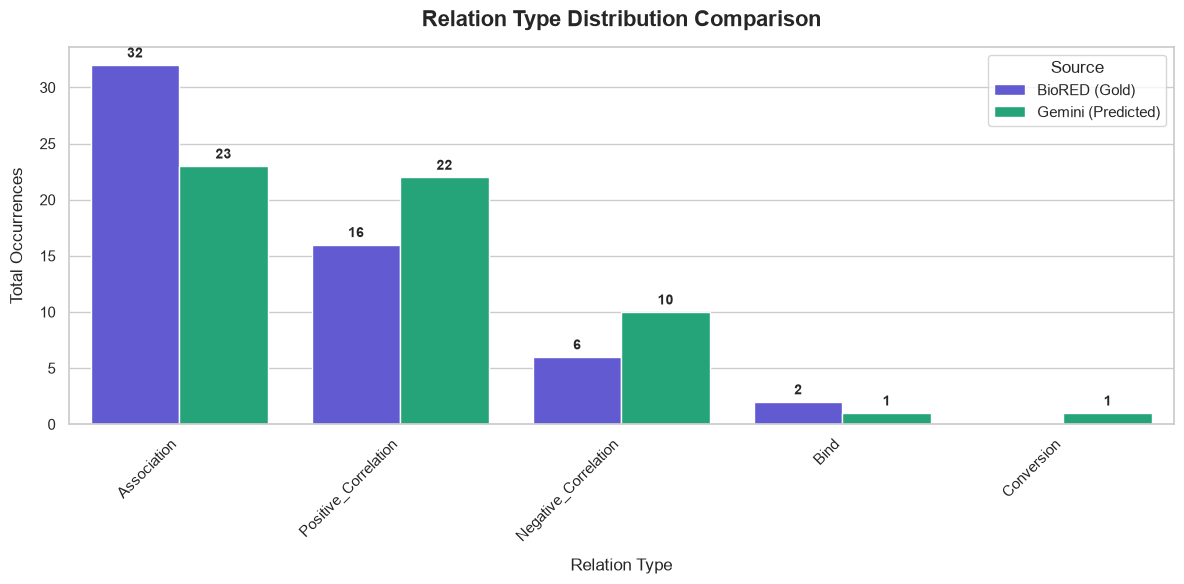

In [98]:
plot_relation_distribution(df_true, gemini_2_5_flash_df_pred)

          RELATION TYPE FREQUENCY REPORT          

--- BioRED (Gold Standard) ---
Relation_Type
Association             32
Positive_Correlation    16
Negative_Correlation     6
Bind                     2
Name: count, dtype: int64

--- Gemini (Predictions) ---
Relation_Type
Association             25
Positive_Correlation    21
Negative_Correlation    10
Bind                     2
Conversion               1
Name: count, dtype: int64


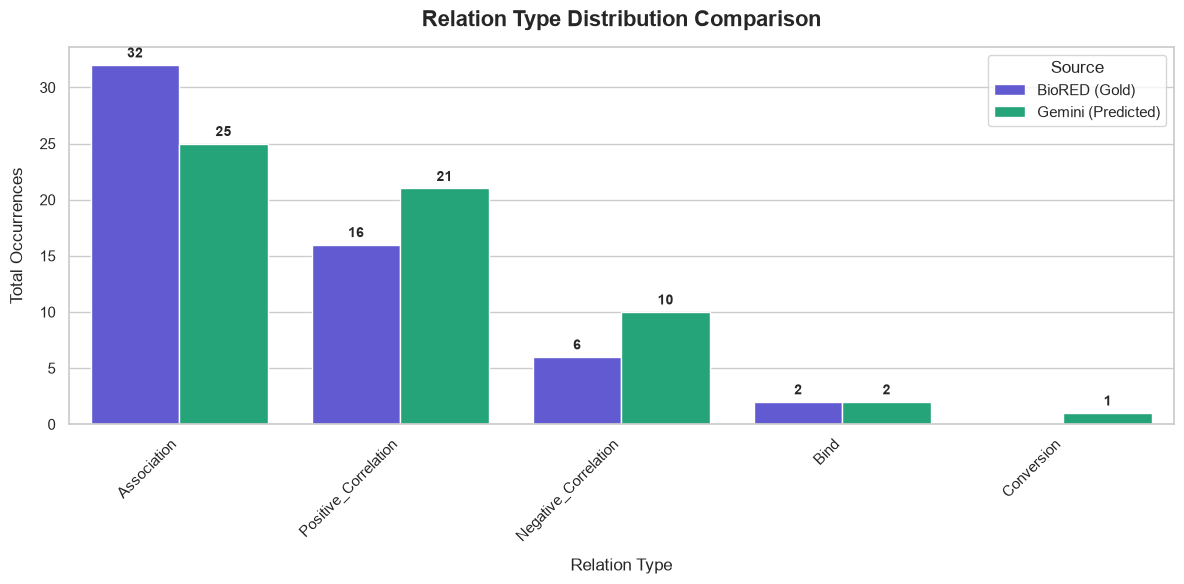

In [99]:
plot_relation_distribution(df_true, gemini_2_5_pro_df_pred)

          RELATION TYPE FREQUENCY REPORT          

--- BioRED (Gold Standard) ---
Relation_Type
Association             3380
Positive_Correlation    1766
Negative_Correlation    1150
Bind                      89
Cotreatment               55
Comparison                39
Drug_Interaction          13
Conversion                 4
Name: count, dtype: int64

--- Gemini (Predictions) ---
Relation_Type
Positive_Correlation    2419
Negative_Correlation    1604
Association             1446
Cotreatment               75
Bind                      74
Comparison                51
Conversion                30
Drug_Interaction          15
Name: count, dtype: int64


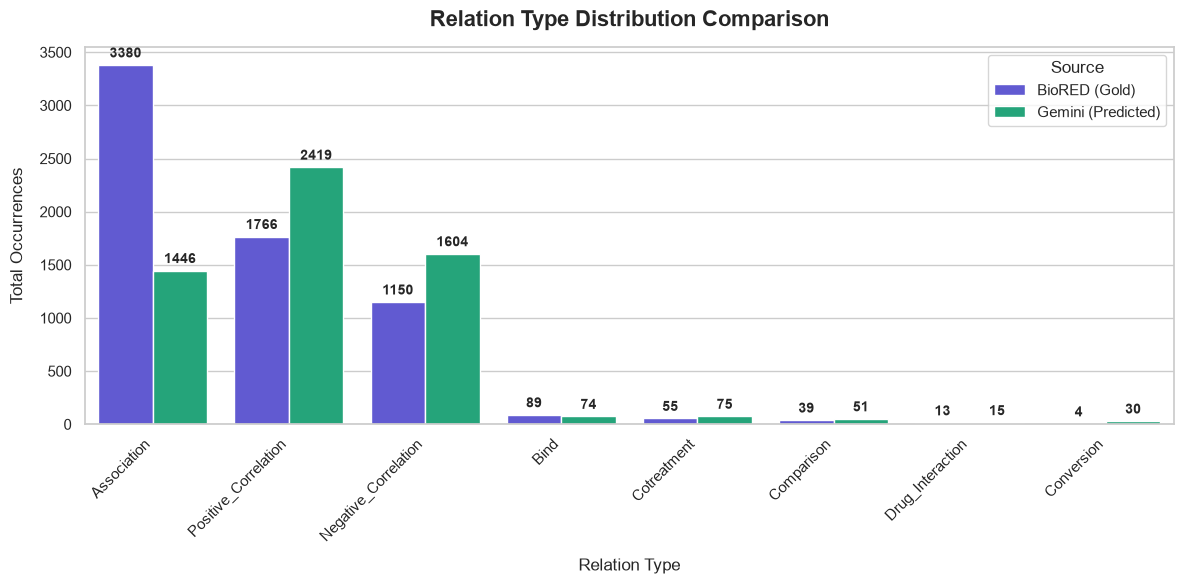

In [116]:
plot_relation_distribution(df_true, full_triple_extraction_df_pred)